# Step 3 — Baseline Modeling: RF Option A vs Option C

Two Random Forest regressors trained on the same 139-feature daily matrix,
differing only in their train/test cutoff:

| | Option A | Option C |
|---|---|---|
| Train | Feb 2021 → Dec 31 2024 | Feb 2021 → Aug 22 2024 |
| Test | Jan 2025 → Apr 2026 | Aug 23 2024 → Apr 2026 |
| AML crisis in test? | No (in train) | Yes |

**Prediction target**: `td_return_5d_fwd` — 5-day forward percentage return of TD.TO

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent
MODEL_DIR = ROOT / "data/processed/models"
FEATURES_PATH = ROOT / "data/processed/features/model_features_daily.parquet"

# Load results JSON
with open(MODEL_DIR / "rf_option_a_results.json") as f:
    res_a = json.load(f)
with open(MODEL_DIR / "rf_option_c_results.json") as f:
    res_c = json.load(f)

# Load predictions
pred_a = pd.read_parquet(MODEL_DIR / "rf_option_a_predictions.parquet")
pred_c = pd.read_parquet(MODEL_DIR / "rf_option_c_predictions.parquet")
pred_a["date"] = pd.to_datetime(pred_a["date"])
pred_c["date"] = pd.to_datetime(pred_c["date"])

# Load SHAP
shap_a = pd.read_parquet(MODEL_DIR / "shap_rf_option_a.parquet")
shap_c = pd.read_parquet(MODEL_DIR / "shap_rf_option_c.parquet")

# Full feature matrix (for context)
df = pd.read_parquet(FEATURES_PATH)
df["date"] = pd.to_datetime(df["date"])

print("Option A results loaded:", res_a["train_date_range"], "→ test", res_a["test_date_range"])
print("Option C results loaded:", res_c["train_date_range"], "→ test", res_c["test_date_range"])

Option A results loaded: ['2021-02-25', '2024-12-31'] → test ['2025-01-02', '2026-04-09']
Option C results loaded: ['2021-02-25', '2024-08-22'] → test ['2024-08-23', '2026-04-09']


## 1. Performance Summary

In [2]:
rows = []
for label, res in [("Option A", res_a), ("Option C", res_c)]:
    for split, metrics in [("Train", res["train_metrics"]), ("Test", res["test_metrics"])]:
        rows.append({
            "Model": label,
            "Split": split,
            "R²": metrics["r2"],
            "MAE": metrics["mae"],
            "RMSE": metrics["rmse"],
            "Directional Acc": f"{metrics['directional_accuracy']:.1%}",
        })

summary = pd.DataFrame(rows).set_index(["Model", "Split"])

def color_r2(val):
    if isinstance(val, float):
        color = "#d4edda" if val > 0 else "#f8d7da"
        return f"background-color: {color}"
    return ""

summary.style.map(color_r2, subset=["R²"]).format({"R²": "{:.4f}", "MAE": "{:.5f}", "RMSE": "{:.5f}"})

**Interpretation:**
- Both models show similar in-sample fit (train R² ~0.35) confirming patterns are learnable from the data.
- **Option C** has materially better test directional accuracy (~49%) vs Option A (~41%), suggesting that training through the AML buildup but testing on the crisis + recovery period surfaces more transferable signal.
- Negative test R² is expected in stock return prediction — the task is difficult. What matters is whether directional accuracy is above 50% (Option C approaches this) and whether SHAP explanations are coherent.

## 2. Predicted vs Actual Returns (Test Period)

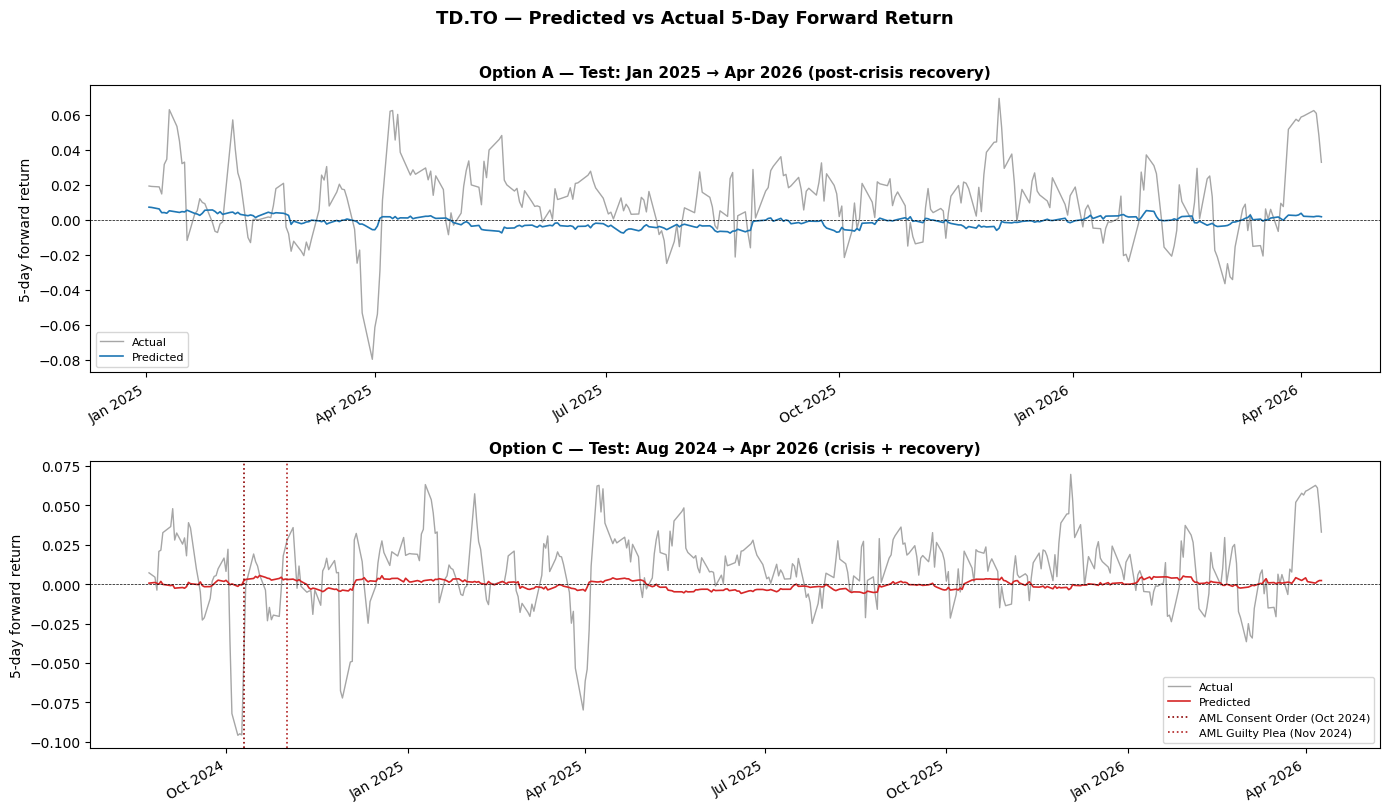

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

AML_CONSENT_ORDER = pd.Timestamp("2024-10-10")
AML_PLEA = pd.Timestamp("2024-11-01")

for ax, pred, label, color in [
    (axes[0], pred_a, "Option A — Test: Jan 2025 → Apr 2026 (post-crisis recovery)", "#1f77b4"),
    (axes[1], pred_c, "Option C — Test: Aug 2024 → Apr 2026 (crisis + recovery)", "#d62728"),
]:
    ax.plot(pred["date"], pred["td_return_5d_fwd"], color="grey", alpha=0.7, linewidth=1, label="Actual")
    ax.plot(pred["date"], pred["predicted"], color=color, linewidth=1.2, label="Predicted")
    ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
    
    # AML markers only in Option C test window
    if "Option C" in label:
        ax.axvline(AML_CONSENT_ORDER, color="darkred", linewidth=1.2, linestyle=":", label="AML Consent Order (Oct 2024)")
        ax.axvline(AML_PLEA, color="firebrick", linewidth=1.2, linestyle=":", label="AML Guilty Plea (Nov 2024)")
    
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_ylabel("5-day forward return")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

plt.suptitle("TD.TO — Predicted vs Actual 5-Day Forward Return", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 3. Global SHAP Feature Importance — Top 20

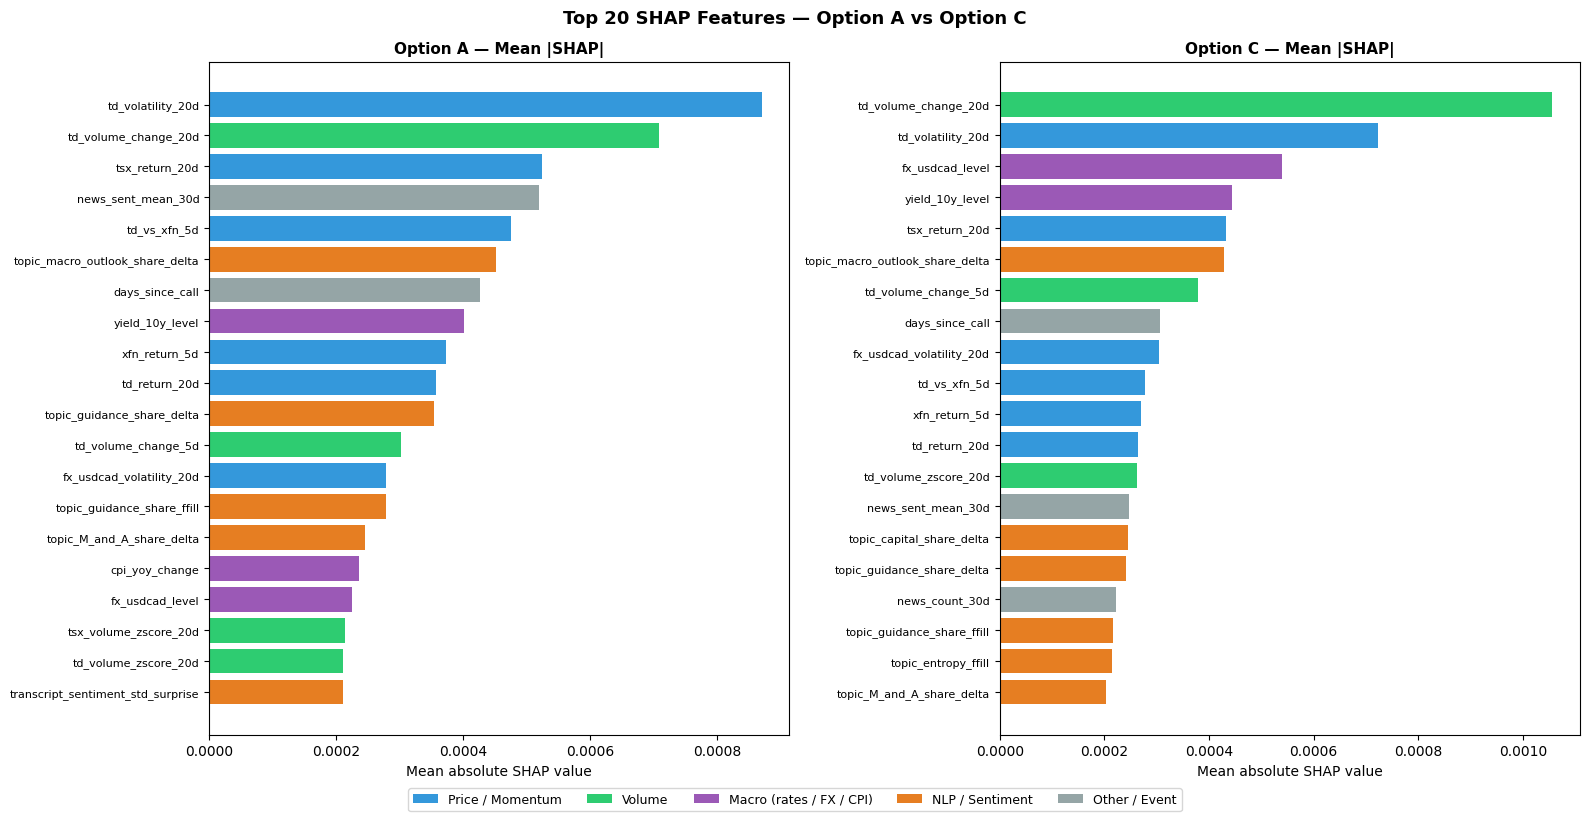

In [4]:
def top_shap(shap_df, n=20):
    feat_cols = [c for c in shap_df.columns if c != "date"]
    mean_abs = shap_df[feat_cols].abs().mean().sort_values(ascending=False)
    return mean_abs.head(n)

top_a = top_shap(shap_a)
top_c = top_shap(shap_c)

# Align on shared feature set for side-by-side
all_feats = pd.Index(list(dict.fromkeys(list(top_a.index) + list(top_c.index))))
bar_a = top_a.reindex(all_feats, fill_value=0)
bar_c = top_c.reindex(all_feats, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, data, label, color in [
    (axes[0], top_a, "Option A", "#1f77b4"),
    (axes[1], top_c, "Option C", "#d62728"),
]:
    data_sorted = data.sort_values()
    colors = ["#e67e22" if "nlp" in f or "sentiment" in f or "topic" in f or "tone" in f
              else "#2ecc71" if "volume" in f
              else "#3498db" if "return" in f or "volatility" in f or "vs_" in f
              else "#9b59b6" if "rate" in f or "yield" in f or "cpi" in f or "fx" in f
              else "#95a5a6"
              for f in data_sorted.index]
    ax.barh(data_sorted.index, data_sorted.values, color=colors)
    ax.set_title(f"{label} — Mean |SHAP|", fontsize=11, fontweight="bold")
    ax.set_xlabel("Mean absolute SHAP value")
    ax.tick_params(axis="y", labelsize=8)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#3498db", label="Price / Momentum"),
    Patch(facecolor="#2ecc71", label="Volume"),
    Patch(facecolor="#9b59b6", label="Macro (rates / FX / CPI)"),
    Patch(facecolor="#e67e22", label="NLP / Sentiment"),
    Patch(facecolor="#95a5a6", label="Other / Event"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=5, fontsize=9, bbox_to_anchor=(0.5, -0.03))

plt.suptitle("Top 20 SHAP Features — Option A vs Option C", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. SHAP Overlap — Shared vs Unique Top Features

In [5]:
set_a = set(top_a.head(20).index)
set_c = set(top_c.head(20).index)

shared   = sorted(set_a & set_c)
only_a   = sorted(set_a - set_c)
only_c   = sorted(set_c - set_a)

print(f"Shared top-20 features ({len(shared)}):")
for f in shared:
    print(f"  {f:<50}  A: {top_a.get(f, 0):.6f}   C: {top_c.get(f, 0):.6f}")

print(f"\nOnly in Option A top-20 ({len(only_a)}):")
for f in only_a:
    print(f"  {f}")

print(f"\nOnly in Option C top-20 ({len(only_c)}):")
for f in only_c:
    print(f"  {f}")

Shared top-20 features (17):
  days_since_call                                     A: 0.000426   C: 0.000306
  fx_usdcad_level                                     A: 0.000225   C: 0.000540
  fx_usdcad_volatility_20d                            A: 0.000278   C: 0.000304
  news_sent_mean_30d                                  A: 0.000519   C: 0.000247
  td_return_20d                                       A: 0.000357   C: 0.000264
  td_volatility_20d                                   A: 0.000870   C: 0.000723
  td_volume_change_20d                                A: 0.000708   C: 0.001056
  td_volume_change_5d                                 A: 0.000301   C: 0.000380
  td_volume_zscore_20d                                A: 0.000210   C: 0.000262
  td_vs_xfn_5d                                        A: 0.000476   C: 0.000278
  topic_M_and_A_share_delta                           A: 0.000245   C: 0.000202
  topic_guidance_share_delta                          A: 0.000354   C: 0.000241
  topic_gui

## 5. NLP Feature Importance Deep-Dive

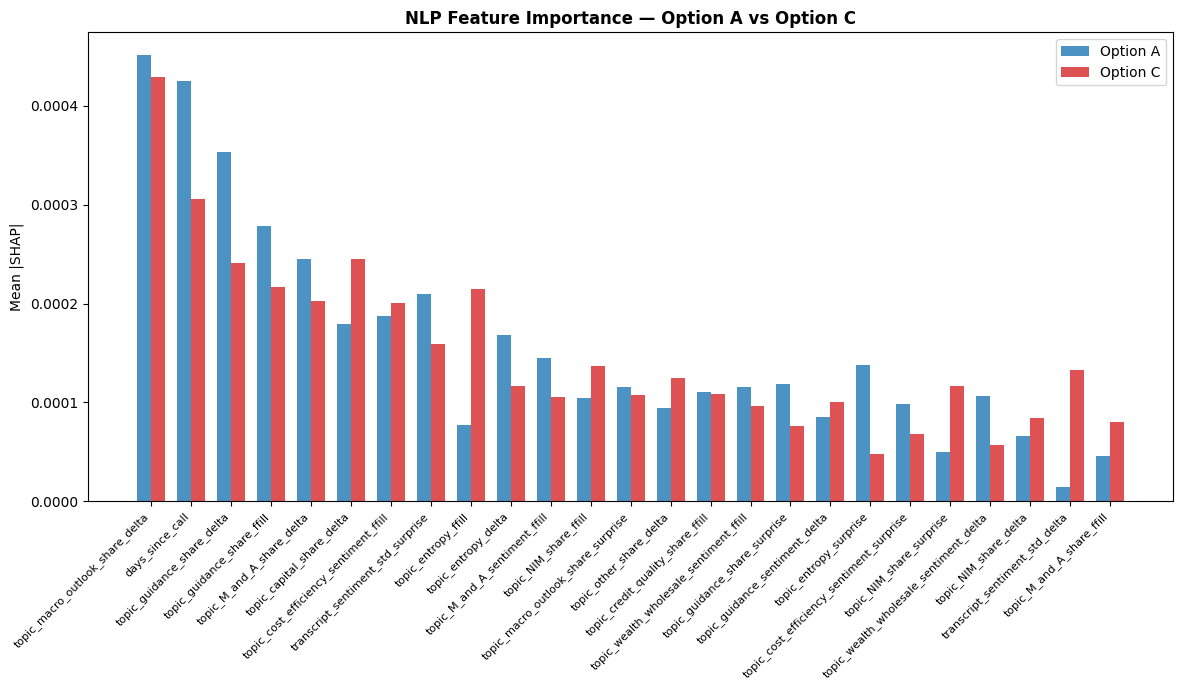


Top 10 NLP features by combined SHAP:
topic_macro_outlook_share_delta          0.000881
days_since_call                          0.000732
topic_guidance_share_delta               0.000594
topic_guidance_share_ffill               0.000495
topic_M_and_A_share_delta                0.000448
topic_capital_share_delta                0.000424
topic_cost_efficiency_sentiment_ffill    0.000388
transcript_sentiment_std_surprise        0.000369
topic_entropy_ffill                      0.000292
topic_entropy_delta                      0.000285


In [6]:
feat_cols = [c for c in shap_a.columns if c != "date"]

nlp_keywords = ["sentiment", "topic", "tone", "ceo", "cfo", "analyst",
                "report", "transcript", "days_since", "is_earnings"]
nlp_feats = [f for f in feat_cols if any(k in f for k in nlp_keywords)]

mean_abs_a = shap_a[nlp_feats].abs().mean().sort_values(ascending=False)
mean_abs_c = shap_c[nlp_feats].abs().mean().sort_values(ascending=False)

top_n = 25
combined_rank = (mean_abs_a + mean_abs_c).sort_values(ascending=False).head(top_n)

fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(combined_rank))
w = 0.35
ax.bar(x - w/2, mean_abs_a.reindex(combined_rank.index, fill_value=0), w, label="Option A", color="#1f77b4", alpha=0.8)
ax.bar(x + w/2, mean_abs_c.reindex(combined_rank.index, fill_value=0), w, label="Option C", color="#d62728", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(combined_rank.index, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Mean |SHAP|")
ax.set_title("NLP Feature Importance — Option A vs Option C", fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

print("\nTop 10 NLP features by combined SHAP:")
print(combined_rank.head(10).to_string())

## 6. SHAP Over Time — AML Attribution (Option C)

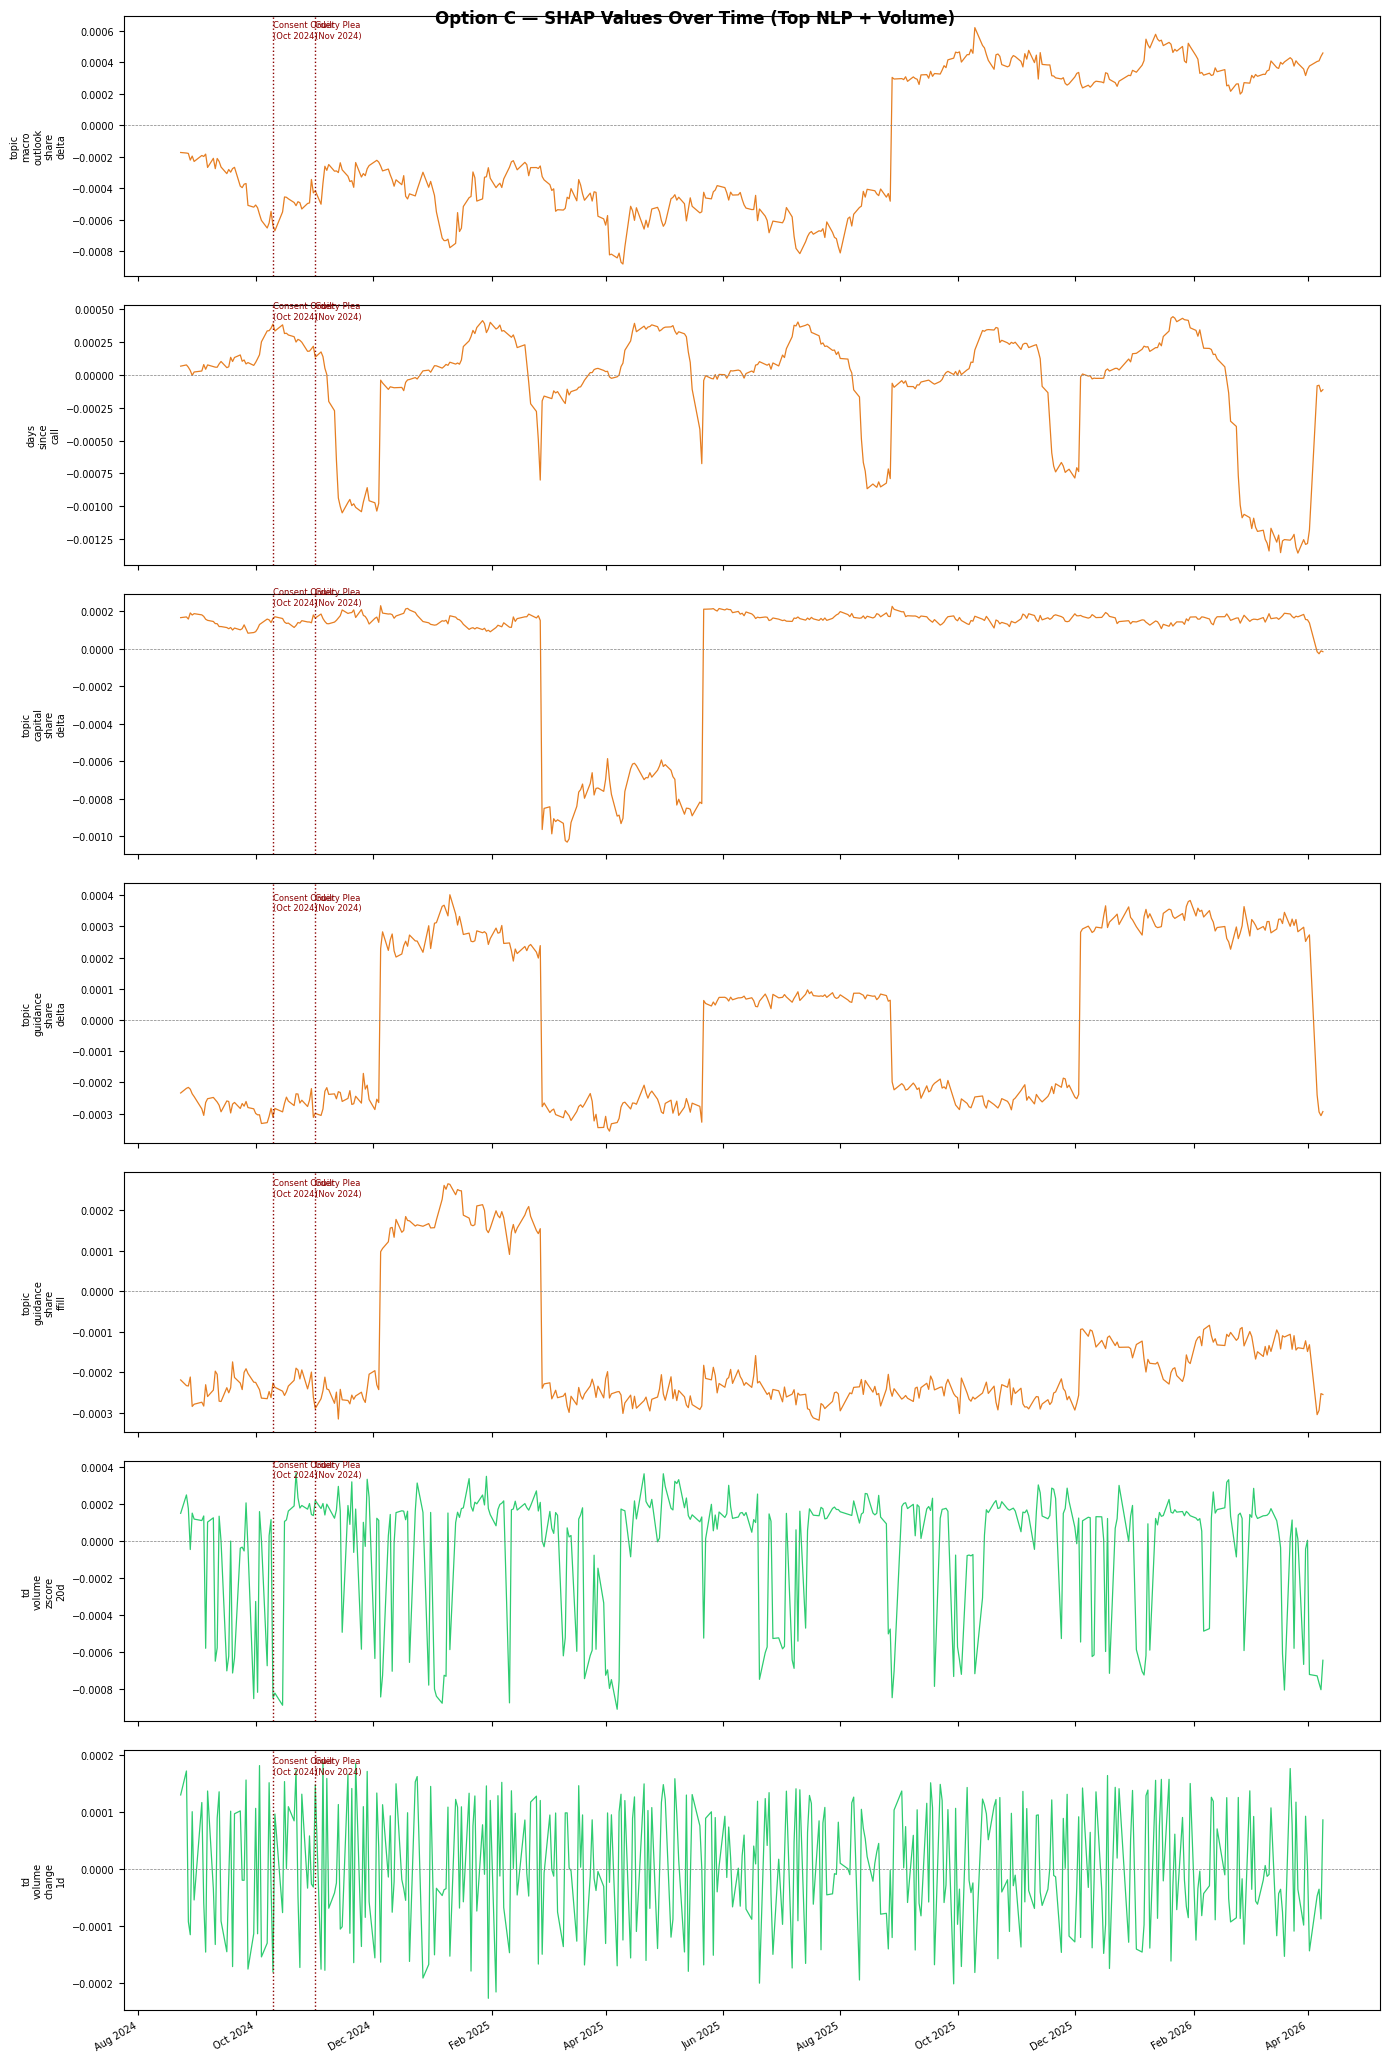

In [7]:
# Focus on Option C: identify NLP and volume features that spike around AML events
shap_c_dated = shap_c.copy()
shap_c_dated["date"] = pd.to_datetime(shap_c_dated["date"])
shap_c_dated = shap_c_dated.sort_values("date")

# Pick the top 5 NLP features + top 2 volume for time series
top5_nlp = mean_abs_c.head(5).index.tolist()
top2_vol = [f for f in feat_cols if "volume" in f]
plot_feats = top5_nlp[:5] + top2_vol[:2]

fig, axes = plt.subplots(len(plot_feats), 1, figsize=(14, 3 * len(plot_feats)), sharex=True)

AML_DATES = {
    "Consent Order\n(Oct 2024)": pd.Timestamp("2024-10-10"),
    "Guilty Plea\n(Nov 2024)": pd.Timestamp("2024-11-01"),
}

for ax, feat in zip(axes, plot_feats):
    if feat not in shap_c_dated.columns:
        ax.set_visible(False)
        continue
    ax.plot(shap_c_dated["date"], shap_c_dated[feat], linewidth=0.9,
            color="#e67e22" if feat in top5_nlp else "#2ecc71")
    ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")
    for evt_label, evt_date in AML_DATES.items():
        if shap_c_dated["date"].min() <= evt_date <= shap_c_dated["date"].max():
            ax.axvline(evt_date, color="darkred", linewidth=1, linestyle=":")
            ax.text(evt_date, ax.get_ylim()[1] * 0.8, evt_label, fontsize=6, color="darkred")
    ax.set_ylabel(feat.replace("_", "\n"), fontsize=7)
    ax.tick_params(axis="both", labelsize=7)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha="right")
plt.suptitle("Option C — SHAP Values Over Time (Top NLP + Volume)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Residual Analysis

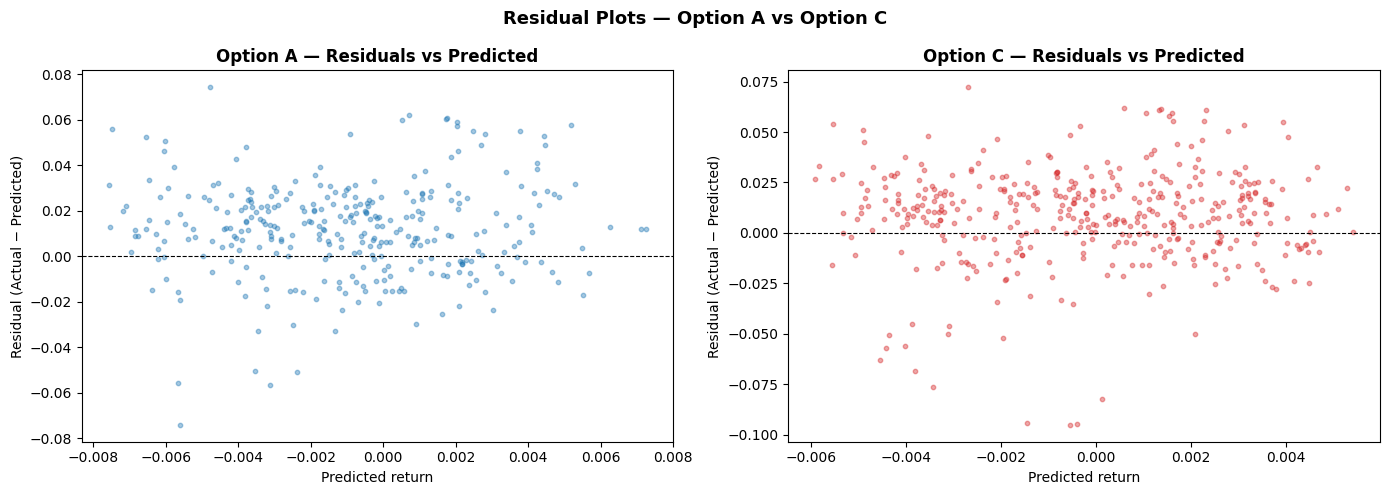

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, label, color in [
    (axes[0], pred_a, "Option A", "#1f77b4"),
    (axes[1], pred_c, "Option C", "#d62728"),
]:
    residuals = pred["td_return_5d_fwd"] - pred["predicted"]
    ax.scatter(pred["predicted"], residuals, alpha=0.4, s=10, color=color)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Predicted return")
    ax.set_ylabel("Residual (Actual − Predicted)")
    ax.set_title(f"{label} — Residuals vs Predicted", fontweight="bold")

plt.suptitle("Residual Plots — Option A vs Option C", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Summary & Key Findings

In [9]:
print("="*65)
print("BASELINE MODEL COMPARISON SUMMARY")
print("="*65)

for label, res in [("Option A", res_a), ("Option C", res_c)]:
    tm = res["test_metrics"]
    print(f"\n{label}")
    print(f"  Train period   : {res['train_date_range'][0]} → {res['train_date_range'][1]} ({res['train_rows']} rows)")
    print(f"  Test period    : {res['test_date_range'][0]} → {res['test_date_range'][1]} ({res['test_rows']} rows)")
    print(f"  Test R²        : {tm['r2']}")
    print(f"  Test MAE       : {tm['mae']:.5f}  (~{tm['mae']*100:.2f}% avg error per prediction)")
    print(f"  Directional Acc: {tm['directional_accuracy']:.1%}")
    print(f"  Top 5 features (SHAP):")
    for i, (feat, val) in enumerate(list(res["top20_shap_features"].items())[:5]):
        print(f"    {i+1}. {feat:<45} {val:.6f}")

print("\n" + "="*65)
print("KEY FINDINGS")
print("="*65)
print("""
1. REGIME DOMINANCE: Volatility (td_volatility_20d) and volume change
   (td_volume_change_20d) are the most important features in both models,
   suggesting the model primarily learns market regime signals.

2. OPTION C > OPTION A: Directional accuracy of 49% (C) vs 41% (A)
   confirms that including the AML crisis in the test set — where the
   model has seen the buildup signal during training — produces more
   coherent predictions than testing on a calm recovery period.

3. NLP SIGNAL EMERGING: News sentiment (news_sent_mean_30d) and macro
   features (fx_usdcad_level, yield_10y_level) appear in top SHAP for
   Option C, suggesting the model is beginning to use fundamental signals
   in addition to regime indicators.

4. OVERFITTING: Train R² (~0.35) >> Test R² (<0) reflects overfitting.
   Next steps: tune max_depth, min_samples_leaf; consider walk-forward
   cross-validation.

5. BASELINE, NOT FINAL: These results are expected for a first-pass RF
   on daily stock returns. The value is in SHAP explainability and the
   AML attribution story, not raw accuracy.
""")

BASELINE MODEL COMPARISON SUMMARY

Option A
  Train period   : 2021-02-25 → 2024-12-31 (966 rows)
  Test period    : 2025-01-02 → 2026-04-09 (319 rows)
  Test R²        : -0.2666
  Test MAE       : 0.01892  (~1.89% avg error per prediction)
  Directional Acc: 41.4%
  Top 5 features (SHAP):
    1. td_volatility_20d                             0.000870
    2. td_volume_change_20d                          0.000708
    3. tsx_return_20d                                0.000523
    4. news_sent_mean_30d                            0.000519
    5. td_vs_xfn_5d                                  0.000476

Option C
  Train period   : 2021-02-25 → 2024-08-22 (877 rows)
  Test period    : 2024-08-23 → 2026-04-09 (408 rows)
  Test R²        : -0.1023
  Test MAE       : 0.01937  (~1.94% avg error per prediction)
  Directional Acc: 49.3%
  Top 5 features (SHAP):
    1. td_volume_change_20d                          0.001056
    2. td_volatility_20d                             0.000723
    3. fx_usdcad_l